# Generative Adversarial Networks (GAN) Image Generation

In this notebook, we will:
1. Load a pretrained GAN model from Hugging Face.
2. Generate random input/noise vectors.
3. Pass the inputs through the Generator.
4. Generate multiple images.
5. Display the generated images using Matplotlib.
6. Experiment with different random inputs.

In [1]:
# Install the necessary libraries if you haven't already
!pip install pytorch-pretrained-biggan huggingface_hub torch torchvision matplotlib numpy nltk


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_pretrained_biggan import BigGAN, one_hot_from_names, truncated_noise_sample
import logging
logging.basicConfig(level=logging.ERROR) # Suppress warnings for cleaner output
import nltk
nltk.download('wordnet')


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\aafre\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## 1. Load a Pretrained GAN Model from Hugging Face

We will use `pytorch-pretrained-biggan`, which loads the BigGAN model hosted on the Hugging Face Hub.

In [3]:
# Load the pretrained BigGAN-deep-256 model
model = BigGAN.from_pretrained('biggan-deep-256')

# Check if GPU is available and move model to GPU for faster generation
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Model loaded and moved to {device}")

Model loaded and moved to cpu


## 2 & 3. Generate Random Inputs and Pass Through the Generator

BigGAN is a conditional GAN, meaning we can tell it what class of image to generate (e.g., 'dog', 'car', 'soap bubble'). We generate a class vector and a random noise vector.

In [4]:
def generate_images(classes, truncation=0.4):
    """
    Helper function to generate images given a list of class names.
    """
    batch_size = len(classes)
    
    # Create class vectors and noise vectors
    class_vector = one_hot_from_names(classes, batch_size=batch_size)
    noise_vector = truncated_noise_sample(truncation=truncation, batch_size=batch_size)

    # Convert to PyTorch tensors and move to device
    noise_tensor = torch.from_numpy(noise_vector).to(device)
    class_tensor = torch.from_numpy(class_vector).to(device)

    # Pass the inputs through the generator
    with torch.no_grad():
        output = model(noise_tensor, class_tensor, truncation)
        
    # Move output back to CPU and process to image format
    output = output.cpu().numpy()
    # Convert from [-1, 1] to [0, 1] and then to [0, 255]
    output = ((output + 1.0) / 2.0) * 255.0
    # Transpose to (batch_size, height, width, channels)
    output = np.transpose(output, ((0, 2, 3, 1)))
    output = output.clip(0, 255).astype(np.uint8)
    
    return output

## 4 & 5. Generate and Display Multiple Images

Let's choose some classes and display the generated images.

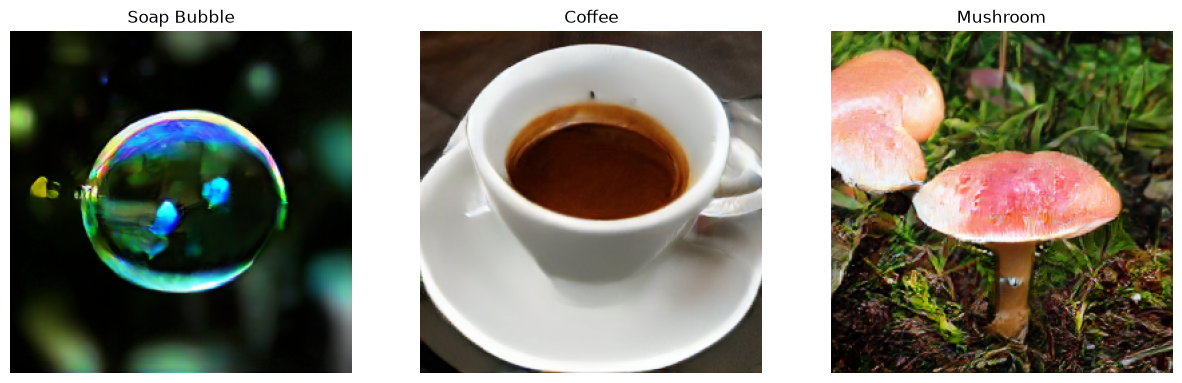

In [5]:
# List of ImageNet classes we want to generate
target_classes = ['soap bubble', 'coffee', 'mushroom']

# Generate the images
generated_images = generate_images(target_classes)

# Display the images using Matplotlib
fig, axes = plt.subplots(1, len(target_classes), figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.imshow(generated_images[i])
    ax.set_title(target_classes[i].title())
    ax.axis('off')
plt.show()

## 6. Experiment with Different Random Inputs

Let's experiment with different classes and truncation values. A lower truncation value generally produces higher quality but less diverse images.

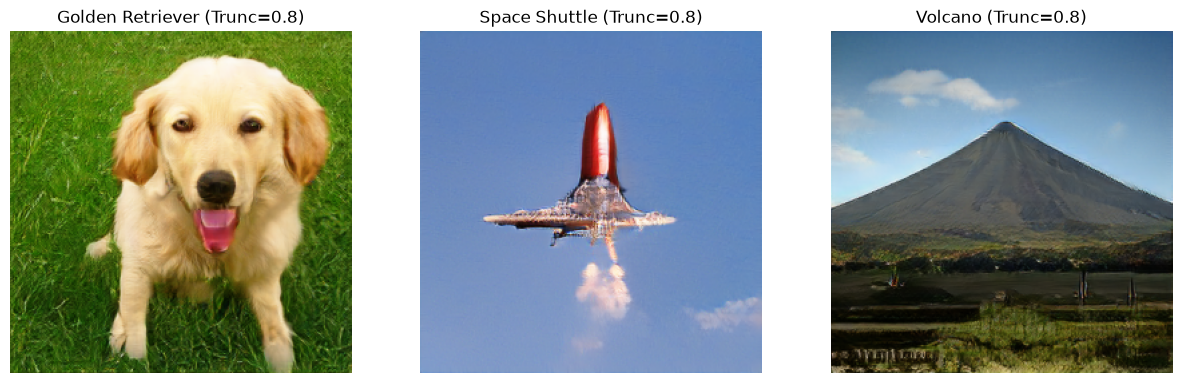

In [6]:
experimental_classes = ['golden retriever', 'space shuttle', 'volcano']

# Let's use a higher truncation for more variety
experimental_images = generate_images(experimental_classes, truncation=0.8)

fig, axes = plt.subplots(1, len(experimental_classes), figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.imshow(experimental_images[i])
    ax.set_title(f"{experimental_classes[i].title()} (Trunc=0.8)")
    ax.axis('off')
plt.show()